In [13]:
from typing import TypedDict, List, Annotated, Optional
from langgraph.graph import StateGraph, START, END, add_messages, MessagesState
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from tavily import TavilyClient
from langchain_core.messages import AIMessage, HumanMessage, BaseMessage, SystemMessage
from exa_py import Exa
from langgraph.types import Send
import os
import json
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser
from IPython.display import Image, display
from db.database import SessionLocal, init_db
from db.crud import create_track, save_syllabus
import re
load_dotenv()
init_db()


In [351]:
llm=ChatGroq(model_name="Llama-3.3-70B-Versatile", api_key=os.getenv('GROQ_API'))

In [352]:
llm.invoke("what is your name").content

'I\'m an artificial intelligence model known as Llama. Llama stands for "Large Language Model Meta AI."'

In [15]:
tavily_client = TavilyClient(api_key=os.getenv('TAVILY_API_KEY'))
response = tavily_client.search("tell me about mutual funds", include_answer=True)
response['answer']


'A mutual fund is a professionally managed investment fund that pools money from many investors to buy a diversified portfolio of stocks, bonds, or other securities. Investors buy shares from the fund, which can offer diversification and professional management. Mutual funds are regulated by the SEC.'

In [2]:
exa = Exa(api_key=os.getenv("EXA_API_KEY"))

result = exa.search(
  "blog post about artificial intelligence",
  type="auto",
  contents={
    "highlights": {
      "max_characters": 4000
    }
  }
)

In [3]:
print(result)

Title: Superintelligence is already here, today - by Noah Smith
URL: https://noahpinion.substack.com/p/superintelligence-is-already-here
ID: https://noahpinion.substack.com/p/superintelligence-is-already-here
Score: None
Published Date: 2026-03-02T00:00:00.000Z
Author: Noah Smith
Image: https://substackcdn.com/image/fetch/$s_!PaoU!,w_1200,h_675,c_fill,f_jpg,q_auto:good,fl_progressive:steep,g_auto/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2Fc67e2d8b-6e4c-40e7-b90a-525b74e2d823_960x540.jpeg
Favicon: https://substackcdn.com/image/fetch/$s_!gj67!,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fbucketeer-e05bbc84-baa3-437e-9518-adb32be77984.s3.amazonaws.com%2Fpublic%2Fimages%2Fa242bd04-28e0-4418-8968-e96e069a8358%2Ffavicon.ico
Extras: None
Subpages: None
Text: None
Summary: None
Highlights: [' Superintelligence is already here, today - by Noah Smith\n\n# Noahpinion\n\nSubscribeSign in  ...    Mar 02, 2026\n\n423\n\n78\n\n49\n\nShare People argue back and for

In [353]:
class SyllabusItem(BaseModel):
    day: int
    title: str
    concepts:List[str]
    
class AgentState(TypedDict):
    topic: str
    total_days: int
    syllabus: list[SyllabusItem]  # [{day, title, goal, concepts}]
    revision_count: int = 0     # tracks retry loops
    quality_score: float = 0.0,
    track_id: int

class Source(BaseModel):
    url: str = Field(description="URL of the source")
    title: str = Field(description="Title of the article")
    content: str = Field(description="Relevant extracted content from the page")
    quality_score: float = Field(
        description="Quality score between 0 and 10",
        ge=0,
        le=10
    )

class FilteredSources(BaseModel):
    filtered_sources: List[Source] = Field(
        description="Top 5 best sources for learning the topic"
    )
    
class SyllabusItem(BaseModel):
    day: int = Field(description="Day number in the syllabus")
    title: str = Field(description="Title for the day")
    concepts: List[str] = Field(
        description="2 to 4 concepts introduced on this day"
    )

class SyllabusOutput(BaseModel):
    syllabus: List[SyllabusItem]


In [354]:
def parse_input(state:AgentState)->AgentState:
    """
    Sanitise and normalise the raw inputs.
    - Strips whitespace / lowercases topic for search consistency
    - Clamps total_days between 3 and 60
    - Resets control-flow flags
    """
    cleaned_topic = state['topic'].strip()
    clamped_days  = max(3, min(60, state['total_days']))
    return {
        "topic":      cleaned_topic,
        "total_days": clamped_days
    }

In [355]:
def search_topic(state: AgentState) -> AgentState:
    """
    Fires 3 Tavily queries and stores raw results in search_results.

    search_depth="advanced" means Tavily fetches full page content,
    so each result has a `raw_content` field with the full article text —
    much richer than a basic snippet search.

    Queries:
      1. how to learn {topic} for beginners
      2. best {topic} learning roadmap
      3. {topic} core concepts fundamentals
    """
    
    topic=state['topic']
    queries = [
        f"how to learn {topic} for beginners complete guide",
        f"best {topic} learning roadmap step by step",
        f"{topic} core concepts fundamentals explained",
    ]
    all_results: list[dict]=[]
    for query in queries:
        try:
            search_result = tavily_client.search(query=query, search_depth="advanced",max_results=3,include_images=False)   
            results = search_result["results"]
            all_results.extend(results)
            print(f"[web_search] '{query}' → {len(search_result['results'])} results")
        except Exception as e:
            print(f"[web_search] Query failed: {query!r} → {e}")
    print(f"[web_search] Total: {len(all_results)} results")
    return {"search_results": all_results}

In [356]:
def filter_search_results(state: AgentState) -> dict:
    """
    Select the best learning sources from Tavily search results
    using structured output.
    """
    
    import re

    def sanitize_text(text: str) -> str:
        if not text:
            return ""
        # Remove non-ASCII / control characters
        text = text.encode("ascii", errors="ignore").decode("ascii")
        # Collapse whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        return text[:300]  # Truncate to avoid token bloat

    topic = state["topic"]

    results = state["search_results"][:10]

    trimmed_results = [
    {
        "url": r.get("url"),
        "title": sanitize_text(r.get("title", "")),
        "content": sanitize_text(r.get("content", "")),
    }
        for r in results
    ]

    # Use default structured output method (no method argument)
    structured_llm = llm.with_structured_output(FilteredSources)

    response: FilteredSources = structured_llm.invoke([
        SystemMessage(
            content=(
                "You are an expert research assistant that selects "
                "high-quality educational learning resources."
            )
        ),
        HumanMessage(
            content=f"""
Topic: {topic}

Below are search results.

Select the **5 best learning resources**.

Prioritize:
- tutorials
- official documentation
- structured beginner guides
- educational articles

Avoid:
- forums
- social media
- discussions

Return the selected sources with:
- url
- title
- a short relevant content excerpt
- quality score (0-10)

Search Results:
{trimmed_results}
"""
        )
    ])

    print(f"[filter_sources] Selected {len(response.filtered_sources)} sources")

    return {
        "filtered_sources": [s.model_dump() for s in response.filtered_sources]
    }


In [357]:
def generate_syllabus(state: AgentState) -> dict:
    structured_llm = llm.with_structured_output(SyllabusOutput)
    response: SyllabusOutput = structured_llm.invoke([
        SystemMessage(content="""You are an expert curriculum designer 
        specialising in beginner-friendly learning paths.
        You MUST return the response using the provided tool schema.
        The output must contain a field called `syllabus`."""),
        HumanMessage(content=f"""
Design a {state['total_days']}-day learning curriculum for: "{state['topic']}"
Target level: beginner

Rules:
1. Day 1 must explain what {state['topic']} is and why it matters
2. Each day must introduce exactly 2–4 concepts
3. Concepts must build logically from previous days
4. Day {state['total_days']} must be a capstone ("putting it all together")
5. Titles should be curiosity-driven and engaging
""")
    ])

    print(f"[generate_syllabus] Generated {len(response.syllabus)} days")
    return {"syllabus": [s.model_dump() for s in response.syllabus]}

In [358]:
def save_to_db(state: AgentState) -> dict:
    """
    Creates a Track row and saves all SyllabusItems to SQLite.
    Returns track_id so downstream systems (Graph 2) can reference it.
    """
    db = SessionLocal()
    try:
        # Create the track
        track = create_track(
            db=db,
            topic=state["topic"],
            total_days=state["total_days"],
        )

        # Save every syllabus item
        save_syllabus(
            db=db,
            track_id=track.id,
            syllabus=state["syllabus"],   # already list[dict] from model_dump()
        )

        print(f"[save_to_db] Track {track.id} saved — {len(state['syllabus'])} days")
        return {"track_id": track.id}

    except Exception as e:
        db.rollback()
        print(f"[save_to_db] Failed: {e}")
        raise
    finally:
        db.close()

In [359]:
def build_curriculum_graph():
    g = StateGraph(AgentState)

    # nodes
    g.add_node("parse_input",       parse_input)
    g.add_node("generate_syllabus", generate_syllabus)
    g.add_node("save_to_db", save_to_db)

    # edges (connections)
    g.add_edge(START, "parse_input")
    g.add_edge("parse_input", "generate_syllabus")
    g.add_edge("generate_syllabus","save_to_db")
    g.add_edge("save_to_db",END)

    # Optionally, return or use the graph
    return g.compile()


In [360]:
curriculum_graph = build_curriculum_graph()

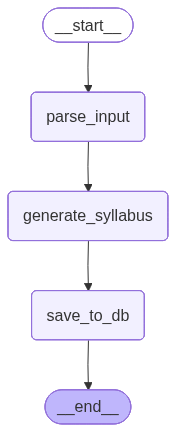

In [361]:
display(Image(curriculum_graph.get_graph().draw_mermaid_png()))

In [362]:
test_state = {
    "topic": "claude 4.6",
    "total_days": 1,
    "syllabus": []}

result = curriculum_graph.invoke(test_state)
print(result)

[generate_syllabus] Generated 3 days
[save_to_db] Track 5 saved — 3 days
{'topic': 'claude 4.6', 'total_days': 3, 'syllabus': [{'day': 1, 'title': "Unlocking the Power of Claude 4.6: What's the Big Deal?", 'concepts': ['Introduction to Claude 4.6', 'History and Evolution', 'Key Features', 'Importance in the Industry']}, {'day': 2, 'title': 'Diving Deeper: How Claude 4.6 Works Its Magic', 'concepts': ['Core Components', 'Technical Capabilities', 'Real-World Applications', 'Common Use Cases']}, {'day': 3, 'title': 'Bringing It All Together: Mastering Claude 4.6 for Real-World Success', 'concepts': ['Practical Implementation', 'Troubleshooting and Optimization', 'Best Practices for Integration', 'Future Developments and Trends']}], 'track_id': 5}


MAKING THE SECOND GRAPH

In [ ]:
exa = Exa(api_key=os.getenv("EXA_API_KEY"))

result = exa.search(
  "blog post about artificial intelligence",
  type="auto",
  num_results=10,
  contents={
    "highlights": {
      "max_characters": 4000
    }
  }
)

In [7]:
class RankedSource(BaseModel):
    url:             str
    title:           str
    relevance_score: float = Field(ge=0, le=10)


class RankedSources(BaseModel):
    sources: List[RankedSource]


class CritiqueResult(BaseModel):
    depth_score:        float = Field(ge=0, le=1, description="Does it go beyond surface knowledge?")
    clarity_score:      float = Field(ge=0, le=1, description="Would a complete beginner follow this?")
    tone_score:         float = Field(ge=0, le=1, description="Does it feel human, not synthetic?")
    repetition_score:   float = Field(ge=0, le=1, description="Does each paragraph introduce something new? 0.0 = same metaphor/sentence repeated 5+ times, 1.0 = every paragraph is fresh")
    needs_revision:     bool  = Field(description="True if any score is below 0.75")
    hook_feedback:      str   = Field(description="Specific feedback for the hook, or 'approved'")
    body_feedback:      str   = Field(description="Specific feedback for the body, or 'approved'")
    practical_feedback: str   = Field(description="Specific feedback for the practical, or 'approved'")
    
    
class DailyContentState(TypedDict):
    # Inputs
    topic:          str
    total_days:     int
    track_id:       int
    syllabus_item:  dict
    previous_title: str | None

    # Phase 1 — raw research
    tavily_results: list[dict]
    exa_results:    list[dict]

    # Phase 2 — merged + ranked sources
    merged_sources: list[dict]

    # Phase 3 — draft sections
    card_hook:      str
    card_body:      str
    card_practical: str

    # Phase 5 — critique loop
    critique_feedback: str
    revision_count:    int
    needs_revision:    bool

    # Phase 6 — final output
    newsletter_md: str
    sources:       list[dict]
    card_ready:    bool

In [8]:
def sanitize(text: str, max_chars: int = 800) -> str:
    if not text:
        return ""
    text = text.encode("ascii", errors="ignore").decode("ascii")
    text = re.sub(r'\s+', ' ', text).strip()
    return text[:max_chars]


def build_source_context(sources: list[dict], max_chars_each: int = 2500) -> str:
    return "\n\n---\n\n".join(
        f"Source: {s['title']}\nURL: {s['url']}\n{s['content'][:max_chars_each]}"
        for s in sources
    )


def concept_list(item: dict) -> str:
    return ", ".join(item["concepts"])

In [16]:
def tavily_search(state: DailyContentState) -> dict:
    """
    Fires concept-targeted Tavily queries for today's syllabus item.
    Queries are specific to today's concepts, not generic topic overviews.
    search_depth='advanced' returns full raw_content per result.
    """
    topic   = state["topic"]
    item    = state["syllabus_item"]
    
    queries = [
        f"{topic} {item['title']}",
        *[f"{topic} {concept} explained" for concept in item["concepts"][:3]],
    ]
    
    all_results: list[dict] = []
    seen_urls: set[str]     = set()
    
    for query in queries:
        try:
            result = tavily_client.search(
                query=query,
                search_depth="advanced",
                type="auto",
                max_results=4,
                include_images=False,
            )
            for r in result["results"]:
                url = r.get("url", "")
                if url and url not in seen_urls:
                    seen_urls.add(url)
                    all_results.append(r)
            print(f"[search] '{query}' → {len(result['results'])} results")
        except Exception as e:
            print(f"[search] Query failed: {query!r} → {e}")

    print(f"[search] Total unique results: {len(all_results)}")
    return {"search_results": all_results}

In [17]:
def exa_search(state: DailyContentState) -> dict:
    """
    Depth-first semantic search — surfaces expert long-form content,
    research breakdowns, and niche analyses that SEO never indexes.
    """

    topic = state["topic"]
    item  = state["syllabus_item"]

    queries = [
        f"deep explanation of {topic} {item['title']}",
        *[f"{topic} {concept} in depth tutorial explanation" for concept in item["concepts"][:2]],
    ]

    all_results: list[dict] = []
    seen_urls: set[str] = set()

    for query in queries:
        try:
            result = exa.search(
                query,
                type="neural",
                num_results=10,
                contents={
                    "text": {
                        "maxCharacters": 5000
                    },
                    "summary": True,
                    "highlights": {
                        "query": f"{topic} {item['title']} explanation examples",
                        "numHighlights": 3,
                        "maxCharacters": 1000
                    }
                }
            )

            for r in result.results:
                url = r.url or ""

                if url and url not in seen_urls:
                    seen_urls.add(url)

                    all_results.append({
                        "url": url,
                        "title": r.title or "",
                        "content": r.text or "",
                        "summary": getattr(r, "summary", ""),
                        "highlights": getattr(r, "highlights", []),
                        "score": r.score or 5.0,
                        "source": "exa"
                    })

            print(f"[exa] '{query}' → {len(result.results)} results")

        except Exception as e:
            print(f"[exa] failed: {query!r} → {e}")

    print(f"[exa] Total unique: {len(all_results)}")

    return {"exa_results": all_results}

In [18]:
def fan_out_research(state: DailyContentState) -> list[Send]:
    return [
        Send("tavily_search", state),
        Send("exa_search",    state),
    ]

In [39]:
def merge_and_rank_sources(state: DailyContentState) -> dict:
    """
    Combine Tavily + Exa, deduplicate, LLM picks top 6 by educational depth.
    Content re-attached after LLM call — no content field in schema.
    """
    item = state["syllabus_item"]

    all_results: list[dict] = []
    seen_urls: set[str] = set()

    for r in state.get("tavily_results", []):
        url = r.get("url", "")
        if url and url not in seen_urls:
            seen_urls.add(url)
            all_results.append({
                "url":     url,
                "title":   r.get("title", ""),
                "content": r.get("raw_content") or r.get("content", ""),
                "score":   r.get("score", 5.0),
                "source":  "tavily",
            })

    for r in state.get("exa_results", []):
        url = r.get("url", "")
        if url and url not in seen_urls:
            seen_urls.add(url)
            all_results.append({
                "url":     url,
                "title":   r.get("title", ""),
                "content": r.get("content", ""),
                "score":   r.get("score", 5.0),
                "source":  "exa",
            })

    if not all_results:
        print("[merge] No results — returning empty")
        return {"merged_sources": []}

    results_by_url = {r["url"]: r for r in all_results}

    summary = "\n\n".join(
        f"URL: {r['url']}\nTitle: {sanitize(r['title'])}\n"
        f"Source: {r['source']}\nSnippet: {sanitize(r['content'], 600)}"
        for r in all_results
    )
    llm=ChatGroq(model_name="Llama-3.3-70B-Versatile", api_key=os.getenv('GROQ_API'))
    structured_llm = llm.with_structured_output(RankedSources)

    try:
        response: RankedSources = structured_llm.invoke([
            SystemMessage(content=(
                "You are selecting the highest-quality educational sources for a learning card. "
                "Favour depth and specificity over popularity. "
                "Exa results are often more expert-level — weight them accordingly."
            )),
            HumanMessage(content=f"""
Today's lesson: "{item['title']}"
Concepts: {concept_list(item)}

Pick the 6 best sources. Prioritise sources that:
- Go deep, not just define terms
- Use real examples, data, or case studies
- Are written by subject matter experts
- Teach something a beginner can't Google in 10 seconds

Avoid: forums, social media, thin explainer pages, paywalled content.

Sources:
{summary}
""")
        ])

        merged = []
        for s in response.sources[:6]:
            original = results_by_url.get(s.url, {})
            merged.append({
                "url":             s.url,
                "title":           s.title,
                "relevance_score": s.relevance_score,
                "content":         original.get("content", ""),
                "source":          original.get("source", ""),
            })

        print(f"[merge] Final source count: {len(merged)}")
        return {"merged_sources": merged}

    except Exception as e:
        print(f"[merge] Structured output failed, using top 6 by score: {e}")
        top6 = sorted(all_results, key=lambda r: r["score"], reverse=True)[:6]
        return {"merged_sources": top6}


In [62]:
WRITER_SYSTEM = SystemMessage(content="""You are writing a daily learning card for someone completely new to this topic.

Your tone is calm, warm, and conversational — like a knowledgeable friend explaining something over coffee.
Never write like a textbook. No bold definitions. No formal headers inside your section.
Write in flowing paragraphs.
When introducing a concept, lead with an analogy or real-world scenario first, then name it.
Simple everyday language throughout. The reader should feel relaxed and genuinely enlightened.""")


def write_hook(state: DailyContentState) -> dict:
    """2-3 sentences that make the reader genuinely curious."""
    item           = state["syllabus_item"]
    topic          = state["topic"]
    previous_title = state.get("previous_title")
    feedback       = state.get("critique_feedback", "")

    revision_note = ""
    if feedback and "hook_feedback" in feedback:
        hook_line = [l for l in feedback.splitlines() if "hook_feedback" in l]
        if hook_line and "approved" not in hook_line[0].lower():
            revision_note = f"\n\nRevise based on this feedback: {hook_line[0]}"

    yesterday = (
        f"The previous card covered: \"{previous_title}\". "
        "Open with one sentence that naturally bridges from there.\n"
        if previous_title else ""
    )
    llm=ChatGroq(model_name="Llama-3.3-70B-Versatile", api_key=os.getenv('GROQ_API'))
    response = llm.invoke([WRITER_SYSTEM, HumanMessage(content=f"""
Write ONLY the hook for a learning card on "{topic}".
Today's lesson: "{item['title']}"
{yesterday}
2-3 sentences only. No headers, no labels, just the sentences.
Make the reader feel why this matters in their real life.
Genuine curiosity — not hype, not a definition.{revision_note}
""")])

    return {"card_hook": response.content.strip()}


def write_body(state: DailyContentState) -> dict:
    """700-1000 words, analogy-first, flowing paragraphs."""
    item     = state["syllabus_item"]
    topic    = state["topic"]
    sources  = state.get("merged_sources", [])
    feedback = state.get("critique_feedback", "")
    is_final = item["day"] == state["total_days"]

    source_context = build_source_context(sources)

    revision_note = ""
    if feedback and "body_feedback" in feedback:
        body_line = [l for l in feedback.splitlines() if "body_feedback" in l]
        if body_line and "approved" not in body_line[0].lower():
            revision_note = f"\n\nRevise based on this feedback: {body_line[0]}"

    capstone = (
        "\nThis is the final day. After covering the concepts, add a short "
        "'Where to go from here' section — 3 concrete directions to explore next."
        if is_final else ""
    )
    llm=ChatGroq(model_name="Llama-3.3-70B-Versatile", api_key=os.getenv('GROQ_API'))
    response = llm.invoke([WRITER_SYSTEM, HumanMessage(content=f"""
Write ONLY the body section for a learning card on "{topic}".
Today's lesson: "{item['title']}"
Concepts to cover: {concept_list(item)}

Rules:
- Write EXACTLY 600-750 words. Count carefully. Stop at 750 words.
- Do not add concluding paragraphs, motivational sign-offs, or summaries.
- End when the concepts are covered. Never repeat the same metaphor or analogy more than once.
- Cover every concept listed
- Lead with a real-world analogy or scenario BEFORE naming each concept
- Flowing paragraphs only — no bullet points, no bold definitions, no subheaders
- Simple language — assume zero prior knowledge
- Use real examples, data, and depth from the source material
- Reader finishes feeling they genuinely understood something new
{capstone}

Source material:
{source_context}{revision_note}
""")])

    return {"card_body": response.content.strip()}


def write_practical(state: DailyContentState) -> dict:
    """One concrete action the reader can take today."""
    item     = state["syllabus_item"]
    topic    = state["topic"]
    feedback = state.get("critique_feedback", "")

    revision_note = ""
    if feedback and "practical_feedback" in feedback:
        practical_line = [l for l in feedback.splitlines() if "practical_feedback" in l]
        if practical_line and "approved" not in practical_line[0].lower():
            revision_note = f"\n\nRevise based on this feedback: {practical_line[0]}"
    llm=ChatGroq(model_name="Llama-3.3-70B-Versatile", api_key=os.getenv('GROQ_API'))
    response = llm.invoke([WRITER_SYSTEM, HumanMessage(content=f"""
Write ONLY the practical section for a learning card on "{topic}".
Today's lesson: "{item['title']}"
Concepts covered: {concept_list(item)}

ONE single concrete action the reader can do today.
Not "read more about it." Something tactile — an observation, a small experiment, a specific thing to try.
2-4 sentences. No header, no label, just the action.{revision_note}
""")])

    return {"card_practical": response.content.strip()}

In [63]:
def fan_out_writing(state: DailyContentState) -> list[Send]:
    return [
        Send("write_hook",      state),
        Send("write_body",      state),
        Send("write_practical", state),
    ]

In [64]:
def consolidate_draft(state: DailyContentState) -> dict:
    """Pure Python — extract clean source list for the newsletter footer."""
    sources = [
        {"title": s["title"], "url": s["url"]}
        for s in state.get("merged_sources", [])[:3]
    ]
    print("[consolidate] Draft assembled")
    return {"sources": sources}

In [73]:
def critique_draft(state: DailyContentState) -> dict:
    """Score depth, clarity, tone. Return structured feedback. Does NOT rewrite."""
    item = state["syllabus_item"]
    
    llm=ChatGroq(model_name="Llama-3.3-70B-Versatile", api_key=os.getenv('GROQ_API'))
    structured_llm = llm.with_structured_output(CritiqueResult)

    try:
        result: CritiqueResult = structured_llm.invoke([
            SystemMessage(content=(
                "You are a rigorous editor for a premium learning newsletter. "
                "You care deeply about whether the reader actually learns something — "
                "not just whether the content sounds correct."
            )),
            HumanMessage(content=f"""
Evaluate this learning card for Day {item['day']}: "{item['title']}"

HOOK:
{state['card_hook']}

BODY:
{state['card_body']}

PRACTICAL:
{state['card_practical']}

Score each 0.0-1.0:

depth_score: Does the body go beyond what anyone already knows?
  0.0 = pure definitions, nothing a Google search wouldn't give
  0.5 = decent overview but lacks examples or insight
  1.0 = teaches something concrete with real examples and analogies

clarity_score: Would a complete beginner genuinely follow this?
  0.0 = jargon-heavy, assumes prior knowledge
  0.5 = mostly clear but has confusing passages
  1.0 = crystal clear, analogy-first, zero assumed knowledge

tone_score: Does it feel human and warm, not synthetic?
  0.0 = reads like Wikipedia or LLM output
  0.5 = mostly fine but has stiff passages
  1.0 = warm and conversational, like a smart friend explaining it

repetition_score: Does the body repeat the same metaphor, analogy, or phrase more than twice?
  0.0 = same metaphor/sentence repeated 5+ times
  0.5 = some repetition but mostly fresh
  1.0 = every paragraph introduces something genuinely new

Set needs_revision=True if ANY of depth_score, clarity_score, tone_score, OR repetition_score is below 0.75.
Give specific actionable feedback per section, or write 'approved'.
""")
        ])

        print(f"[critique] depth={result.depth_score:.2f} clarity={result.clarity_score:.2f} tone={result.tone_score:.2f} needs_revision={result.needs_revision}")

        feedback = (
            f"hook_feedback: {result.hook_feedback}\n"
            f"body_feedback: {result.body_feedback}\n"
            f"practical_feedback: {result.practical_feedback}"
        )

        return {
            "needs_revision":    result.needs_revision,
            "critique_feedback": feedback,
        }

    except Exception as e:
        print(f"[critique] Failed: {e} — approving draft")
        return {"needs_revision": False, "critique_feedback": ""}

In [74]:
def route_critique(state: DailyContentState) -> str:
    revision_count = state.get("revision_count", 0)
    if state.get("needs_revision") and revision_count < 2:
        print(f"[route] Triggering revision {revision_count + 1}")
        return "revise"
    print("[route] Approved — formatting newsletter")
    return "format"

In [75]:
def increment_revision(state: DailyContentState) -> dict:
    return {"revision_count": state.get("revision_count", 0) + 1}

In [82]:
def voice_pass(state: DailyContentState) -> dict:
    """
    Rewrites approved sections for voice, punch, and rhythm.
    Facts stay the same. Tone becomes engaging, not encyclopedic.
    """
    item = state["syllabus_item"]

    system = SystemMessage(content="""You are a senior editor at a premium learning newsletter — 
think The Neuron or Morning Brew but for education.

Your job is NOT to rewrite the content. Your job is to make it more enjoyable to read.

Rules:
- Shorten long sentences. Break walls of text into 2-3 sentence paragraphs.
- Add occasional wit or personality — a wry observation, a relatable aside.
- Use italics for emphasis and humor, not bold definitions.
- The hook should feel like a friend leaning across the table to tell you something.
- Cut any sentence that starts with "According to" or "It is important to note".
- Cut throat-clearing phrases like "In conclusion" or "As we can see".
- Every paragraph should make the reader want to read the next one.
- Keep all facts, examples, and analogies intact — just make them land better.""")

    hook_response = llm.invoke([system, HumanMessage(content=f"""
Rewrite this hook with more punch and personality.
Keep it 2-3 sentences. Make the reader lean in.

Original hook:
{state['card_hook']}
""")])

    body_response = llm.invoke([system, HumanMessage(content=f"""
Rewrite this body with better rhythm, shorter paragraphs, and more personality.
All facts and analogies must stay. Just make it more enjoyable to read.
Target: 700-900 words. Mix paragraph lengths.

Original body:
{state['card_body']}
""")])

    practical_response = llm.invoke([system, HumanMessage(content=f"""
Rewrite this practical to be more specific and energising.
1-3 sentences. Should feel like something you actually want to do today.

Original practical:
{state['card_practical']}
""")])

    return {
        "card_hook":      hook_response.content.strip(),
        "card_body":      body_response.content.strip(),
        "card_practical": practical_response.content.strip(),
    }

In [76]:
def format_newsletter(state: DailyContentState) -> dict:
    """Pure Python — render approved sections into clean newsletter markdown."""
    item    = state["syllabus_item"]
    sources = state.get("sources", [])

    source_lines = "\n".join(
        f"- [{s['title']}]({s['url']})"
        for s in sources
    )

    newsletter = f"""# Day {item['day']} of {state['total_days']} — {item['title']}
*{state['topic']}*

---

{state['card_hook']}

---

{state['card_body']}

---

**Try this today**

{state['card_practical']}

---

**Sources**

{source_lines}
"""

    print("[format] Newsletter markdown ready")
    return {"newsletter_md": newsletter, "card_ready": True}

In [85]:
def build_graph():
    g = StateGraph(DailyContentState)

    # -----------------------------
    # Nodes
    # -----------------------------
    g.add_node("tavily_search",          tavily_search)
    g.add_node("exa_search",             exa_search)
    g.add_node("merge_and_rank_sources", merge_and_rank_sources)

    g.add_node("write_hook",             write_hook)
    g.add_node("write_body",             write_body)
    g.add_node("write_practical",        write_practical)

    g.add_node("consolidate_draft",      consolidate_draft)
    g.add_node("critique_draft",         critique_draft)
    g.add_node("increment_revision",     increment_revision)

    g.add_node("voice_pass",             voice_pass)  # ✅ missing node added
    g.add_node("format_newsletter",      format_newsletter)

    # -----------------------------
    # Phase 1: Research (parallel)
    # -----------------------------
    g.add_conditional_edges(
        START,
        fan_out_research,
        ["tavily_search", "exa_search"]
    )

    g.add_edge("tavily_search", "merge_and_rank_sources")
    g.add_edge("exa_search",    "merge_and_rank_sources")

    # -----------------------------
    # Phase 2: Writing (parallel)
    # -----------------------------
    g.add_conditional_edges(
        "merge_and_rank_sources",
        fan_out_writing,
        ["write_hook", "write_body", "write_practical"]
    )

    g.add_edge("write_hook",      "consolidate_draft")
    g.add_edge("write_body",      "consolidate_draft")
    g.add_edge("write_practical", "consolidate_draft")

    # -----------------------------
    # Phase 3: Critique Loop
    # -----------------------------
    g.add_edge("consolidate_draft", "critique_draft")

    g.add_conditional_edges(
        "critique_draft",
        route_critique,
        {
            "revise": "increment_revision",
            "format": "voice_pass",
        },
    )

    # -----------------------------
    # Phase 4: Revision loop
    # -----------------------------
    g.add_conditional_edges(
        "increment_revision",
        fan_out_writing,
        ["write_hook", "write_body", "write_practical"]
    )

    # -----------------------------
    # Phase 5: Final formatting
    # -----------------------------
    g.add_edge("voice_pass", "format_newsletter")
    g.add_edge("format_newsletter", END)

    return g.compile()

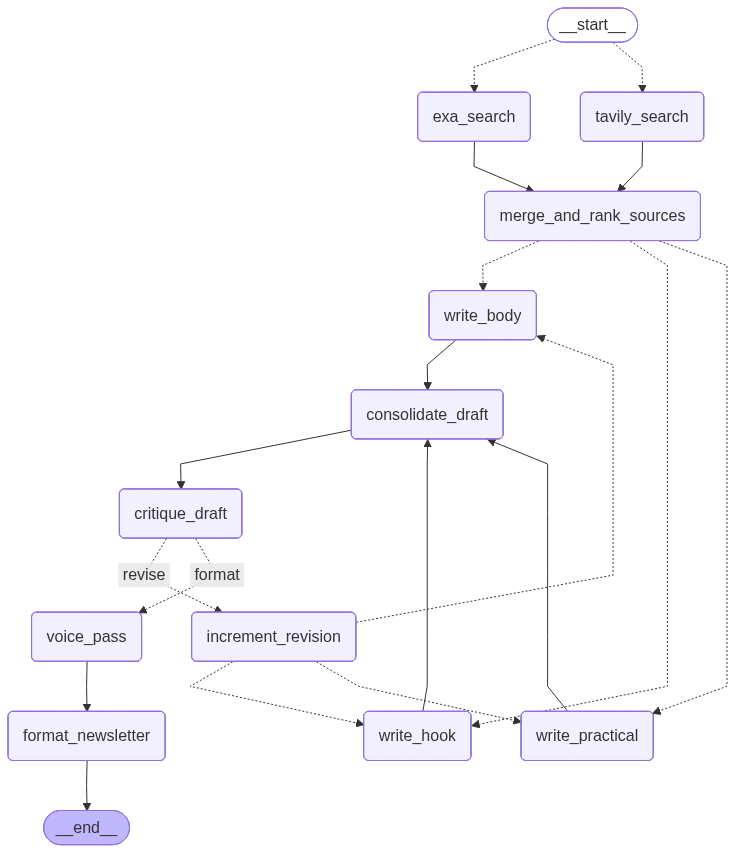

In [86]:
card_writer=build_graph()
display(Image(card_writer.get_graph().draw_mermaid_png()))

In [87]:
def run_daily_content_generator(
    track_id:       int,
    topic:          str,
    total_days:     int,
    syllabus_item:  dict,
    previous_title: str | None = None,
) -> DailyContentState:
    card_writer=build_graph()
    return card_writer.invoke({
        "topic":             topic,
        "total_days":        total_days,
        "track_id":          track_id,
        "syllabus_item":     syllabus_item,
        "previous_title":    previous_title,
        "tavily_results":    [],
        "exa_results":       [],
        "merged_sources":    [],
        "card_hook":         "",
        "card_body":         "",
        "card_practical":    "",
        "critique_feedback": "",
        "revision_count":    0,
        "needs_revision":    False,
        "newsletter_md":     "",
        "sources":           [],
        "card_ready":        False,
        "messages":          [],
    })

In [ ]:
result = run_daily_content_generator(
        track_id=1,
        topic="Mutual Funds",
        total_days=3,
        syllabus_item={
            "day": 1,
            "title": "Unlocking the Power of Mutual Funds: An Introduction",
            "concepts": ["What are Mutual Funds", "Benefits of Investing in Mutual Funds", "Types of Mutual Funds"],
        },
        previous_title=None,
    )

[search] 'Mutual Funds Unlocking the Power of Mutual Funds: An Introduction' → 4 results
[search] 'Mutual Funds What are Mutual Funds explained' → 4 results
[exa] 'deep explanation of Mutual Funds Unlocking the Power of Mutual Funds: An Introduction' → 10 results
[search] 'Mutual Funds Benefits of Investing in Mutual Funds explained' → 4 results
[search] 'Mutual Funds Types of Mutual Funds explained' → 4 results
[search] Total unique results: 14


In [81]:
def print_card(result: DailyContentState):
    item      = result["syllabus_item"]
    separator = "=" * 65

    print(f"\n{separator}")
    print(f"  DAY {item['day']} OF {result['total_days']}  —  {result['topic'].upper()}")
    print(f"{separator}")
    print(f"  {item['title']}")
    print(separator)

    print("\n🪝  HOOK\n")
    print(result["card_hook"])

    print("\n📖  BODY\n")
    print(result["card_body"])

    print("\n✅  TRY THIS TODAY\n")
    print(result["card_practical"])

    print("\n🔗  SOURCES\n")
    for s in result["sources"]:
        print(f"   • {s['title']}")
        print(f"     {s['url']}")

    print(f"\n{separator}")
    print(f"  revisions={result['revision_count']}  |  card_ready={result['card_ready']}")
    print(separator)
    print()
print_card(result)


  DAY 1 OF 3  —  MUTUAL FUNDS
  Unlocking the Power of Mutual Funds: An Introduction

🪝  HOOK

Imagine having a team of experts manage your money, spreading it across different investments to minimize risk and maximize returns. You've probably heard friends or family members talk about their experiences with this type of investment, but maybe you're not entirely sure how it works or if it's right for you. As you start thinking about your long-term financial goals, like buying a house or retiring comfortably, you might be wondering if there's a way to make your money grow without needing to be an investment expert yourself.

📖  BODY

Imagine you're planning a trip to a foreign country, and you're not sure which cities to visit or how to get around. You could try to navigate everything on your own, but it might be overwhelming and time-consuming. Instead, you could join a guided tour, where a knowledgeable guide takes care of all the logistics and shows you the best sights. This is simi